In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatRangeSlider
from IPython.display import display

file_path = "/home/exov3/Documents/Knee_CTRL/Ilseung_LG_ep5_k.npz"
data = np.load(file_path)
keys = list(data.keys())
for i in range(len(keys)):
    print(keys[i])

time = data['time']
knee_angle_l = data['knee_angle_l']
knee_angle_r = data['knee_angle_r']
cmd_l = data['cmd_L']
cmd_r = data['cmd_R']
gyro_thigh_r = data['gyro_thigh_r']
gyro_shank_r = data['gyro_shank_r']

time
knee_angle_r
knee_angle_l
knee_angle_r_u_gyr
knee_angle_l_u_gyr
gyro_thigh_r
gyro_shank_r
cmd_L
cmd_R
K_r
Soft_ctrl_r
K_l
Soft_ctrl_l
GPIO


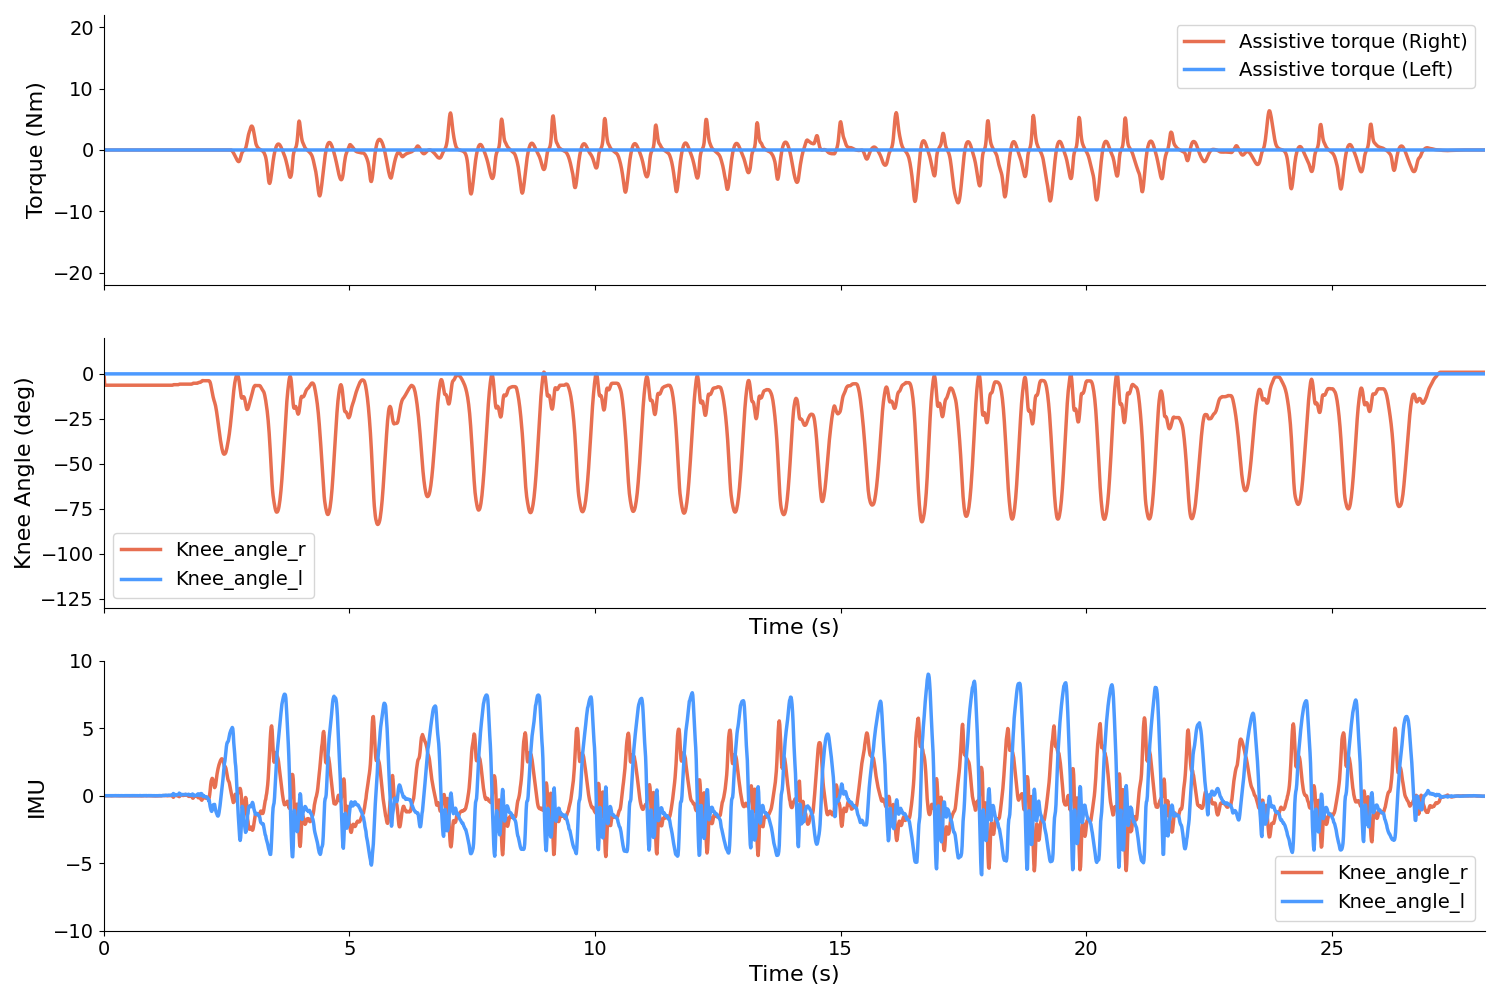

FloatRangeSlider(value=(0.01015534500004378, 28.11004368300007), description='Time range', max=28.110043683000…

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(15,10), sharex=True)

color_r = "#E76F51"
color_l = "#4C9AFF"

line_torque_r, = axs[0].plot(time, cmd_r, color=color_r, linewidth=2.5, label='Assistive torque (Right)')
line_torque_l, = axs[0].plot(time, cmd_l, color=color_l, linewidth=2.5, label='Assistive torque (Left)')
axs[0].set_ylabel("Torque (Nm)", fontsize=16)
axs[0].legend(fontsize=14)
axs[0].set_ylim(-22, 22)
axs[0].set_xlim(0, time[-1])
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].tick_params(axis='both', labelsize=14)

line_knee_angle_r, = axs[1].plot(time, knee_angle_r, color=color_r, linewidth=2.5, label='Knee_angle_r')
line_knee_angle_l, = axs[1].plot(time, knee_angle_l, color=color_l, linewidth=2.5, label='Knee_angle_l')
axs[1].set_ylabel("Knee Angle (deg)", fontsize=16)
axs[1].set_xlabel("Time (s)", fontsize=16)
axs[1].legend(fontsize=14)
axs[1].set_ylim(-130, 20)
axs[1].set_xlim(0, time[-1])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].tick_params(axis='both', labelsize=14)

line_gyro_thigh_r, = axs[2].plot(time, gyro_thigh_r, color=color_r, linewidth=2.5, label='Knee_angle_r')
line_gyro_shank_r, = axs[2].plot(time, gyro_shank_r, color=color_l, linewidth=2.5, label='Knee_angle_l')
axs[2].set_ylabel("IMU", fontsize=16)
axs[2].set_xlabel("Time (s)", fontsize=16)
axs[2].legend(fontsize=14)
axs[2].set_ylim(-10, 10)
axs[2].set_xlim(0, time[-1])
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

slider = FloatRangeSlider(
    value=[time[0], time[-1]],
    min=time[0],
    max=time[-1],
    step=0.01,
    description='Time range'
)

def update(change):
    t0, t1 = slider.value
    mask = (time >= t0) & (time <= t1)

    line_torque_r.set_data(time[mask], cmd_r[mask])
    axs[0].set_xlim(t0, t1)
    axs[0].relim()
    axs[0].autoscale_view()

    line_torque_l.set_data(time[mask], cmd_l[mask])
    axs[0].set_xlim(t0, t1)
    axs[0].relim()
    axs[0].autoscale_view()

    line_knee_angle_r.set_data(time[mask], knee_angle_r[mask])
    axs[1].set_xlim(t0, t1)
    axs[1].relim()
    axs[1].autoscale_view()

    line_knee_angle_l.set_data(time[mask], knee_angle_l[mask])
    axs[1].set_xlim(t0, t1)
    axs[1].relim()
    axs[1].autoscale_view()

    line_gyro_thigh_r.set_data(time[mask], line_gyro_thigh_r[mask])
    axs[2].set_xlim(t0, t1)
    axs[2].relim()
    axs[2].autoscale_view()

    line_gyro_shank_r.set_data(time[mask], line_gyro_shank_r[mask])
    axs[2].set_xlim(t0, t1)
    axs[2].relim()
    axs[2].autoscale_view()

    fig.canvas.draw_idle()

slider.observe(update, names='value')
display(slider)